# 1_eda_and_preprocessing
Project: Clinical Document Classification — EDA & Preprocessing

This notebook performs exploratory data analysis (EDA) and builds the TF-IDF preprocessing pipeline.
Follow instructions in markdown cells; run cells top-to-bottom.


## 1.0 Setup
Install required packages and import libraries. The notebook assumes you have internet access to download the dataset from Hugging Face.

In [1]:
%%bash
python -m pip install --upgrade pip >/dev/null
pip install -q scikit-learn pandas matplotlib seaborn wordcloud datasets joblib

bash: line 1: python: command not found


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import joblib
import os
print('imports ok')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


imports ok


## 1.1 Download Dataset
We will load the `hpe-ai/medical-cases-classification-tutorial` dataset from Hugging Face. If you have already downloaded the files locally, replace this loading code with local file reads.

In [10]:
# Load dataset from Hugging Face
dataset = load_dataset('hpe-ai/medical-cases-classification-tutorial')
dataset

Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['description', 'transcription', 'sample_name', 'medical_specialty', 'keywords'],
        num_rows: 1724
    })
    validation: Dataset({
        features: ['description', 'transcription', 'sample_name', 'medical_specialty', 'keywords'],
        num_rows: 370
    })
    test: Dataset({
        features: ['description', 'transcription', 'sample_name', 'medical_specialty', 'keywords'],
        num_rows: 370
    })
})

In [4]:
# Convert to pandas DataFrame (train/validation/test)
train_df = pd.DataFrame(dataset['train'])
val_df = pd.DataFrame(dataset['validation'])
test_df = pd.DataFrame(dataset['test'])

print(train_df.shape, val_df.shape, test_df.shape)
train_df.head()

(1724, 5) (370, 5) (370, 5)


,description,transcription,sample_name,medical_specialty,keywords
0,Pacemaker ICD interrogation. Severe nonischem...,"PROCEDURE NOTE: , Pacemaker ICD interrogation....",Pacemaker Interrogation,Cardiovascular / Pulmonary,"cardiovascular / pulmonary, cardiomyopathy, ve..."
1,"Erythema of the right knee and leg, possible s...","PREOPERATIVE DIAGNOSES: , Erythema of the righ...",Aspiration - Knee Joint,Orthopedic,"orthopedic, knee and leg, anterolateral portal..."
2,Left cardiac catheterization with selective ri...,"PREOPERATIVE DIAGNOSIS: , Post infarct angina....",Cardiac Cath & Selective Coronary Angiography,Cardiovascular / Pulmonary,"cardiovascular / pulmonary, selective, angiogr..."
3,Patient with a history of coronary artery dise...,"REASON FOR VISIT: , Acute kidney failure.,HIST...",Acute Kidney Failure,Nephrology,None
4,Cardiac evaluation and treatment in a patient ...,"REASON FOR REFERRAL: , Cardiac evaluation and ...",Cardiac Consultation - 6,Cardiovascular / Pulmonary,None


## 1.2 EDA: basic statistics
Analyze document lengths, class distribution, most common words, and keywords.

In [5]:
for name, df in [('train', train_df), ('validation', val_df), ('test', test_df)]:
    df['trans_length'] = df['transcription'].fillna('').str.split().apply(len)
    print(name, 'count:', len(df), 'mean tokens:', int(df['trans_length'].mean()), 'median:', int(df['trans_length'].median()))


train count: 1724 mean tokens: 503 median: 427
validation count: 370 mean tokens: 516 median: 431
test count: 370 mean tokens: 487 median: 422


Text(0.5, 1.0, 'Class distribution (train)')

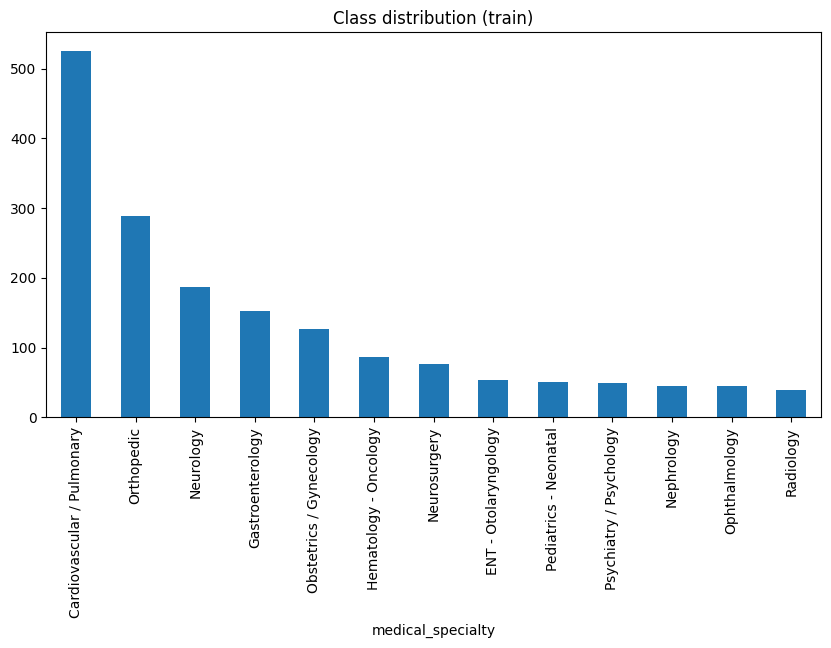

In [6]:
# Plot class distribution in training set
plt.figure(figsize=(10,5))
train_df['medical_specialty'].value_counts().plot(kind='bar')
plt.title('Class distribution (train)')


## 1.3 Preprocessing with TfidfVectorizer
We create a Scikit-learn pipeline using TfidfVectorizer. This cell explains configuration and builds a vectorizer object.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_df=0.9,
    min_df=2,
    ngram_range=(1,2)
)
X_train_text = train_df['transcription'].fillna('')
tfidf.fit(X_train_text)
print('Vocabulary size:', len(tfidf.vocabulary_))


Vocabulary size: 104781


In [8]:
# Save fitted vectorizer for later use
os.makedirs('artifacts', exist_ok=True)
joblib.dump(tfidf, 'artifacts/tfidf_vectorizer.joblib')
print('Saved artifacts/tfidf_vectorizer.joblib')


Saved artifacts/tfidf_vectorizer.joblib


## 1.4 Key findings (placeholders)
Document observations here after you run the EDA: class imbalance, common terms per class, document lengths, any preprocessing decisions (e.g., handling abbreviations).